# Applied ML (BUAN 6341.002 - S24) - Group 4
**Members:**

* Manognya Mandapaka - MXM220140
* Akhila Rondla - AXR210239
* Ankitha Keshavamurthy - AXK230092
* Pallavi Arora - PXA220043
* John Jiang - JXJ200018


**Data Reference:**

This project utilizes data from the [Vehicle Sales Data](https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data?resource=download) publicly available on Kaggle.

## Data Cleaning

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.ticker as ticker

#### 1.Data Loading and Reading

In [2]:
cars = pd.read_csv('car_prices.csv')
print(cars.shape)
print()
print('Keys of carsales:\n',cars.keys())

(558837, 16)

Keys of carsales:
 Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate'],
      dtype='object')


In [3]:
print(cars.head(5))

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

#### 2.Data Sumary and Description

##### 2.1 Data Sumary 

In [4]:
# a.Data type
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


##### 2.2 Data Description

In [5]:
# a.Numerical Data Describe
my_perc = [0.01, 0.25,0.5, 0.75, 0.99]

cars.describe(percentiles = my_perc)

,year,condition,odometer,mmr,sellingprice
count,558837.000000,547017.000000,558743.000000,558799.000000,558825.000000
mean,2010.038927,30.672365,68320.017767,13769.377495,13611.358810
std,3.966864,13.402832,53398.542821,9679.967174,9749.501628
min,1982.000000,1.000000,1.000000,25.000000,1.000000
1%,1998.000000,1.000000,3292.840000,750.000000,500.000000
25%,2007.000000,23.000000,28371.000000,7100.000000,6900.000000
50%,2012.000000,35.000000,52254.000000,12250.000000,12100.000000
75%,2013.000000,42.000000,99109.000000,18300.000000,18200.000000
99%,2015.000000,49.000000,226668.800000,44900.000000,44900.000000
max,2015.000000,49.000000,999999.000000,182000.000000,230000.000000


In [6]:
# b.check the levels of catogory variables
for col in cars.columns:
    if cars[col].dtype == 'object':
        print(f'{col}: {len(cars[col].unique())}')

make: 97
model: 974
trim: 1964
body: 88
transmission: 5
vin: 550298
state: 64
color: 47
interior: 18
seller: 14263
saledate: 3767


#### 3. Data Cleaning and  Type Transform

##### 3.1 Duplication Record Cleaning

In [7]:
#a. Data Duplication Check
num_duplicated_car=cars.duplicated().sum()
print('The number of duplicated car is:',num_duplicated_car)

The number of duplicated car is: 0


In [8]:
#b.transform all string values to lower letter strings
for col in cars.columns:
    if cars[col].dtype=='object':
        cars[col]=cars[col].str.lower()

##### 3.2 Moving Useless Columns

In [9]:
# a.I first check the correlation between mmr and sellingprice 
#mmr isThe MMR (Manheim Market Report) is an estimation of wholesale vehicle values 
#based on comprehensive analysis of millions of actual transaction data in the automotive auction market.)
corr_mmr_sale=cars['mmr'].corr(cars['sellingprice'])
print(corr_mmr_sale)

0.98363475250627


In [10]:
#As they are highly correlated, we must remove it to avoid overfitting issue

In [11]:
# b.Remove useless columns:'vin','seller','mmr'
cars=cars.drop(['vin','seller','mmr'],axis=1)

##### 3.3 Handle Missing Value

In [12]:
#a. Missing Value Check(cells)
missing_value_per_column=cars.isnull().sum()
print(missing_value_per_column)

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
state               0
condition       11820
odometer           94
color             749
interior          749
sellingprice       12
saledate           12
dtype: int64


In [13]:
# Missing value check (records)
rows_with_missing_value=cars.isnull().any(axis=1).sum()
print(rows_with_missing_value)

86512


In [14]:
# b.drop missing value record.
#As our total sample is closed to 600,000,droping about 10,000 records with None value doesn't matter
#I drop rows with none in body first, 
#and check whether it will reduce None record in other columns missing value situation again
cars=cars.dropna(subset=['body'])
missing_value_per_column=cars.isnull().sum()
print(missing_value_per_column)

year                0
make                0
model              98
trim                0
body                0
transmission    63189
state               0
condition       11226
odometer           85
color             728
interior          728
sellingprice       12
saledate           12
dtype: int64


In [15]:
#It also reduce none record in other columns. 
#Now,I dorp condition with none value,and check
cars=cars.dropna(subset=['condition'])
missing_value_per_column=cars.isnull().sum()
print(missing_value_per_column)

year                0
make                0
model              98
trim                0
body                0
transmission    61422
state               0
condition           0
odometer           26
color             638
interior          638
sellingprice       12
saledate           12
dtype: int64


In [16]:
# I will drop record with missing value in all columns except for 'transmission' which is more than 60,000 record
cars=cars.dropna(subset=['model','odometer','color','interior','sellingprice','saledate'])
missing_value_per_column=cars.isnull().sum()
print(missing_value_per_column)

year                0
make                0
model               0
trim                0
body                0
transmission    61323
state               0
condition           0
odometer            0
color               0
interior            0
sellingprice        0
saledate            0
dtype: int64


In [17]:
#c.I begin cleaning None value in transmission without drop
# First check levels and their counts
transmission_counts=cars['transmission'].value_counts()
print(transmission_counts)

transmission
automatic    455963
manual        16362
Name: count, dtype: int64


In [18]:
#As manual only ocupy 16362/61323=2.6%. I decide to use "automatic" to fill the empty value within the transmission column
cars['transmission']=cars['transmission'].fillna('unknown')
missing_value_per_column=cars.isnull().sum()
print(missing_value_per_column)

year            0
make            0
model           0
trim            0
body            0
transmission    0
state           0
condition       0
odometer        0
color           0
interior        0
sellingprice    0
saledate        0
dtype: int64


In [19]:
print(cars.shape)

(533648, 13)


In [20]:
transmission_counts_1=cars['transmission'].value_counts()
print(transmission_counts_1)

transmission
automatic    455963
unknown       61323
manual        16362
Name: count, dtype: int64


##### 3.4 Change Data type

In [21]:
#a.transfer saledate to just sale years
cars['saledate'] = cars['saledate'].str.split().str[3].astype(int)
print(cars['saledate'].head())

0    2014
1    2014
2    2015
3    2015
4    2014
Name: saledate, dtype: int32


In [22]:
# b.transfer object to category variables
for col in cars.columns:
    if cars[col].dtype=='object':
        cars[col]=cars[col].astype('category')

In [23]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 533648 entries, 0 to 558836
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype   
---  ------        --------------   -----   
 0   year          533648 non-null  int64   
 1   make          533648 non-null  category
 2   model         533648 non-null  category
 3   trim          533648 non-null  category
 4   body          533648 non-null  category
 5   transmission  533648 non-null  category
 6   state         533648 non-null  category
 7   condition     533648 non-null  float64 
 8   odometer      533648 non-null  float64 
 9   color         533648 non-null  category
 10  interior      533648 non-null  category
 11  sellingprice  533648 non-null  float64 
 12  saledate      533648 non-null  int32   
dtypes: category(8), float64(3), int32(1), int64(1)
memory usage: 27.6 MB


## Data Visualization

In [25]:
cars.shape

(533648, 13)

In [26]:
# Selecting one/multiple columns through [] operator
Contributing_fact = ['year','condition','odometer','saledate','transmission']
cars[Contributing_fact]

#df[  ['SalePrice', 'OverallQual']   ]

,year,condition,odometer,saledate,transmission
0,2015,5.0,16639.0,2014,automatic
1,2015,5.0,9393.0,2014,automatic
2,2014,45.0,1331.0,2015,automatic
3,2015,41.0,14282.0,2015,automatic
4,2014,43.0,2641.0,2014,automatic
...,...,...,...,...,...
558832,2015,45.0,18255.0,2015,unknown
558833,2012,5.0,54393.0,2015,automatic
558834,2012,48.0,50561.0,2015,automatic
558835,2015,38.0,16658.0,2015,automatic


### Selling Price for Vehicles from 1990 to 2015

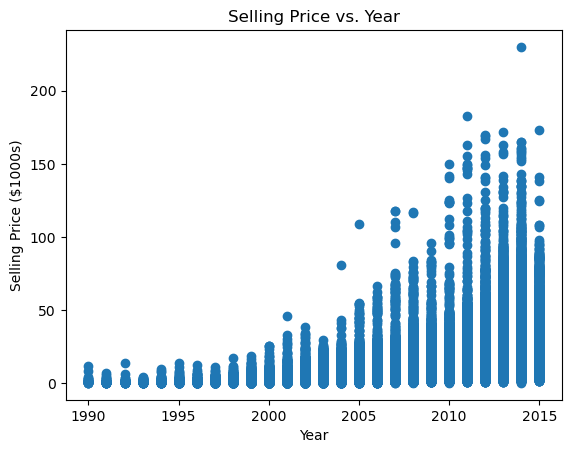

In [27]:
plt.scatter(cars['year'], cars['sellingprice'] / 1000)  # Dividing by 1000 to display in thousands
plt.xlabel('Year')
plt.ylabel('Selling Price ($1000s)')
plt.title('Selling Price vs. Year')
plt.show()

### Vehicle Condition Rating

E:\New folder\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


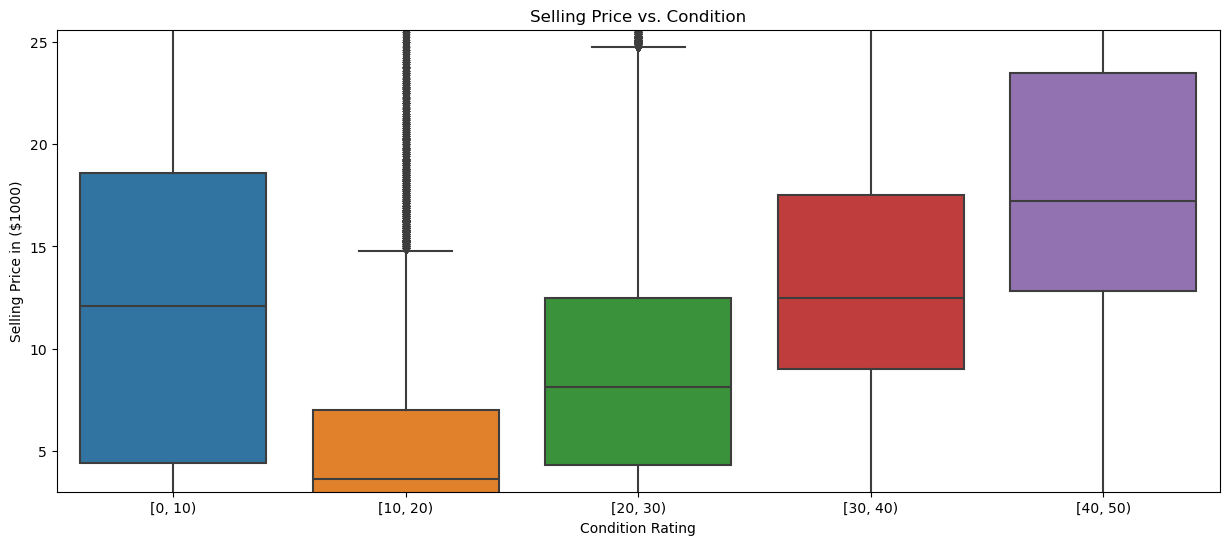

In [28]:
# Create bins for condition variable
bins = range(0, 60, 10)  # bins from 0 to 50 in steps of 10

# Cut the 'condition' variable into bins
cars['condition_bins'] = pd.cut(cars['condition'], bins, right=False)

# Group by 'condition_bins' and calculate the median selling price for each bin
median_prices = cars.groupby('condition_bins', observed=True)['sellingprice'].median().reset_index()

# Plotting
plt.figure(figsize=(15, 6))
sns.boxplot(x='condition_bins', y=cars['sellingprice'] / 1000, data=cars, order=median_prices['condition_bins'])
plt.xlabel('Condition Rating')
plt.ylabel('Selling Price in ($1000)')
plt.title('Selling Price vs. Condition')
plt.xticks(rotation=0)  # Rotate x-axis labels for better readability
plt.ylim(cars['sellingprice'].quantile(0.1) / 1000, cars['sellingprice'].quantile(0.9) / 1000)
plt.show()

# Optionally, remove the 'condition_bins' column after plotting
cars.drop(columns=['condition_bins'], inplace=True)


### Selling Price based of Odometer reading 

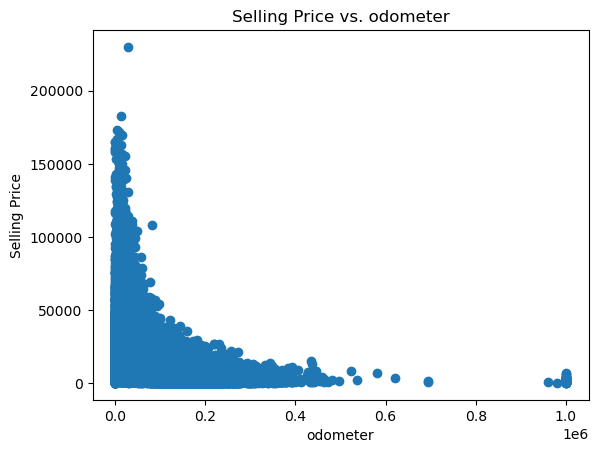

In [29]:
plt.scatter(cars['odometer'], cars['sellingprice'])
plt.xlabel('odometer')
plt.ylabel('Selling Price')
plt.title('Selling Price vs. odometer')
plt.show()

### Relationship between transmission type & odometer with Selling Price 

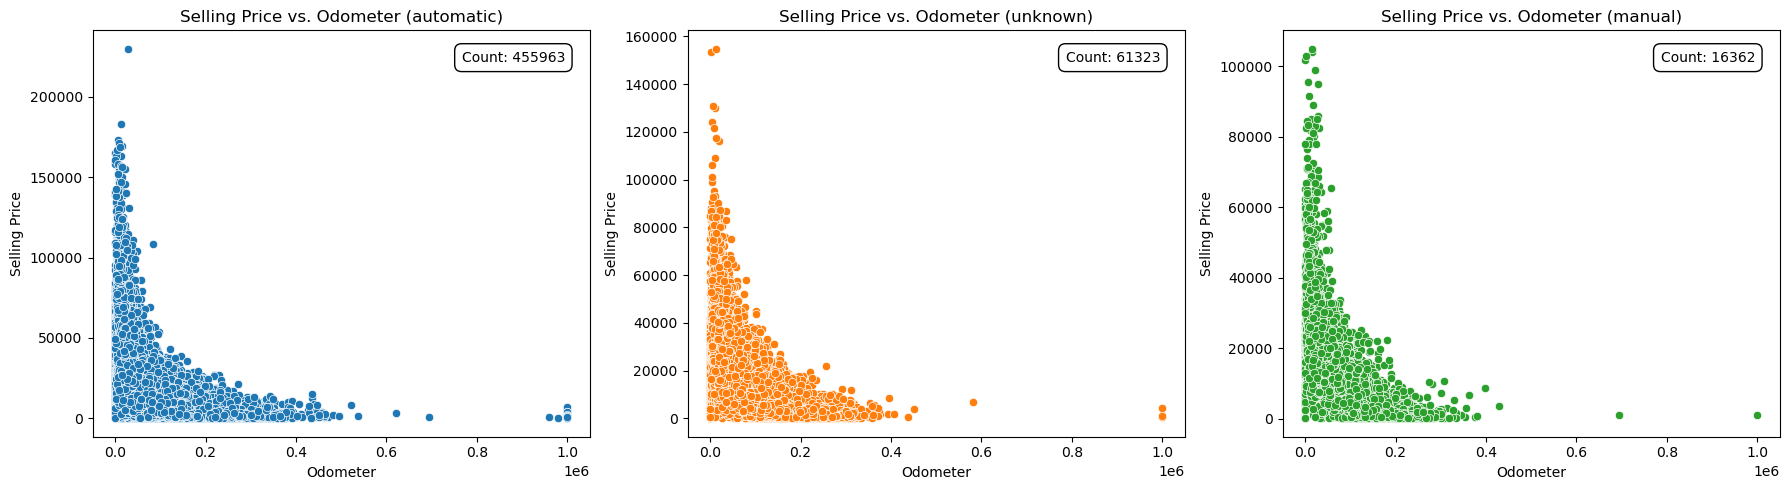

In [32]:
# Get unique transmission types
transmission_types = cars['transmission'].unique()

# Plotting each transmission type separately
plt.figure(figsize=(18, 5))

for i, transmission_type in enumerate(transmission_types):
    plt.subplot(1, 3, i+1)
    subset_df = cars[cars['transmission'] == transmission_type]
    sns.scatterplot(x='odometer', y='sellingprice', data=subset_df, color='C{}'.format(i))
    plt.xlabel('Odometer')
    plt.ylabel('Selling Price')
    plt.title('Selling Price vs. Odometer ({})'.format(transmission_type))
    count_label = 'Count: {}'.format(len(subset_df))
    plt.text(0.95, 0.95, count_label, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


plt.tight_layout()
plt.show()

### Selling Price variation due to age of the vehicle

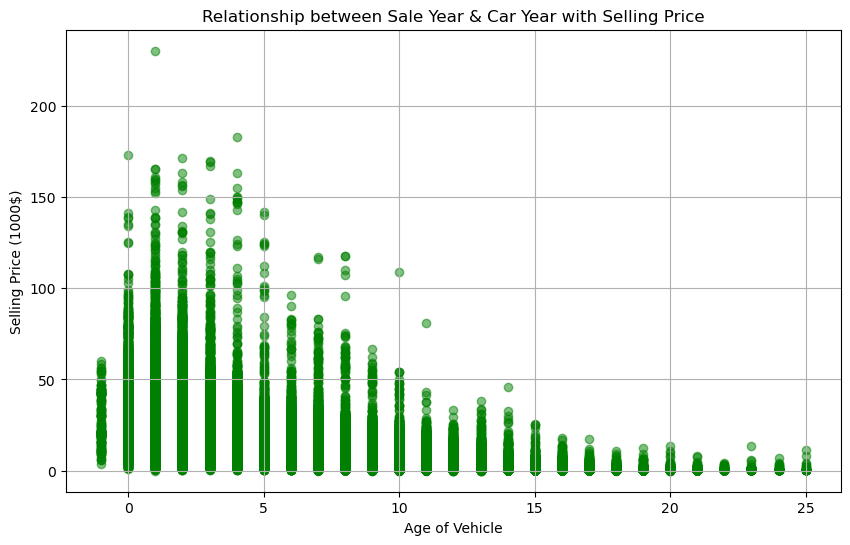

In [34]:
# Create a new column for the difference between 'saledate' and 'year'
cars['year_difference'] = cars['saledate'] - cars['year']

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(cars['year_difference'], cars['sellingprice']/1000, alpha=0.5, color='green')
plt.xlabel('Age of Vehicle')
plt.ylabel('Selling Price (1000$)')
plt.title('Relationship between Sale Year & Car Year with Selling Price')
plt.grid(True)
plt.show()

# Remove the 'year_difference' column after plotting
cars.drop(columns=['year_difference'], inplace=True)


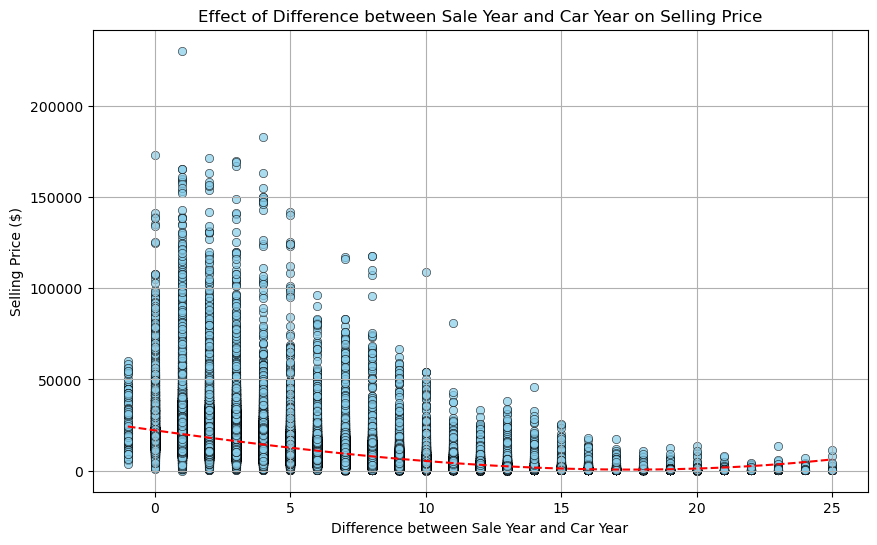

In [41]:
# Create a new column for the difference between 'saledate' and 'year'
cars['year_difference'] = cars['saledate'] - cars['year']

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(cars['year_difference'], cars['sellingprice'], alpha=0.7, c='skyblue', edgecolors='black', linewidth=0.5)
plt.xlabel('Difference between Sale Year and Car Year')
plt.ylabel('Selling Price ($)')
plt.title('Effect of Difference between Sale Year and Car Year on Selling Price')
plt.grid(True)

# Fitting a polynomial curve
p = np.polyfit(cars['year_difference'], cars['sellingprice'], 3)  # Adjust the degree as needed
xp = np.linspace(cars['year_difference'].min(), cars['year_difference'].max(), 100)
yp = np.polyval(p, xp)
plt.plot(xp, yp, 'r--')

plt.show()

# Remove the 'year_difference' column after plotting
cars.drop(columns=['year_difference'], inplace=True)



##### Additional Graphs

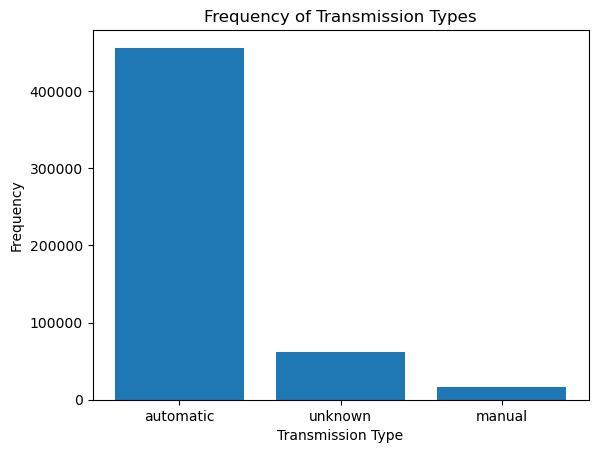

In [35]:
# Transmission Distribution
transmission_counts = cars['transmission'].value_counts()
plt.bar(transmission_counts.index, transmission_counts.values)
plt.title('Frequency of Transmission Types')
plt.xlabel('Transmission Type')
plt.ylabel('Frequency');

### HeatMap and Correlation Matrix

In [37]:
# Correlation matrix to Check the relationship between numerical variables
var = ['sellingprice','year','condition','odometer','saledate']
my_corr_matrix = cars[var].corr()
my_corr_matrix

,sellingprice,year,condition,odometer,saledate
sellingprice,1.000000,0.579093,0.316452,-0.576545,0.032925
year,0.579093,1.000000,0.332918,-0.775187,0.045879
condition,0.316452,0.332918,1.000000,-0.313025,0.020935
odometer,-0.576545,-0.775187,-0.313025,1.000000,-0.027966
saledate,0.032925,0.045879,0.020935,-0.027966,1.000000


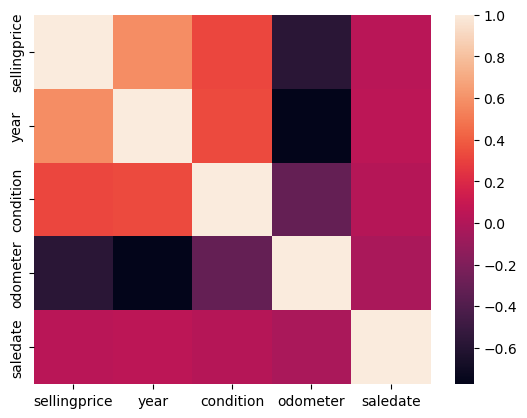

In [38]:
# heatmap to show correlations
sns.heatmap(my_corr_matrix );

## Model Building

## Part 1 

### Model 1: The Bench Mark

#### A. Linear Regression Model before data pre-processing
As all category variable in this step without encoding transfer, we cannot use them to build our model. Therefore, we will use all numerical variables to train the Linear regression model.

In [40]:
var=['year','condition','odometer','saledate']
X=cars[var]
y=cars['sellingprice']

# Split training and testing dataset.
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42) 
# I use the default setting (Testing set=25%)

# Train the linear regression model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
np.set_printoptions(precision=4,suppress=True)
print('model coefficients:\n',lr.coef_)
print('model intercept:\n{:.4f}'.format(lr.intercept_))

model coefficients:
 [773.1645  86.6704  -0.0559 307.9658]
model intercept:
-2159869.3215


In [41]:
## Get R-squared value for training and testing set
R_train=lr.score(X_train,y_train)
print('R-square training set:\n',R_train)
R_test=lr.score(X_test,y_test)
print('R-square test set:\n',R_test)

R-square training set:
 0.3881041247920054
R-square test set:
 0.39171271647841155


In [42]:
# The R-square shows the model can explain about 39% variation of the dataset.
# It performs very close in training set and testing set.
# Observe the coefficients:1.The making year of cars has the largeast coefficient 773.
# 2.The saling year has the second largest coefficient 307.
# They imply that the newest car(large making year and large saling year number) will have the higheast saling price.
# In addition, following the time past, there might be a currency depreciation trend that higher the saling price.

#### B. Data Pre-processing

##### a. MinMax Scalling

In [44]:
# MinMax Scalling
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler(feature_range=(0,1)) # Scale to range 0 to 1, which is default

# Train our scaler
minmax.fit(X_train) # obtaining min and max for X_train

# Get scaled variables
X_train_minmax = minmax.transform(X_train) # use same scaler (i.e., min and max from X_train) to scale
X_test_minmax = minmax.transform(X_test)

In [45]:
#### b. Standard Scaler

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_standar = scaler.transform(X_train) 
X_test_standar = scaler.transform(X_test)

#### C. Linear Regression Model after Scaling

##### a. Linear regression with Minmax scaling data

In [48]:
# Train the model
lr.fit(X_train_minmax,y_train)
np.set_printoptions(precision=4,suppress=True)
print('model coefficients:\n',lr.coef_)
print('model intercept:\n{:.4f}'.format(lr.intercept_))

model coefficients:
 [ 19329.1137   4160.1802 -55881.7246    307.9658]
model intercept:
-942.1676


In [49]:
# We observe the absolute value of intercept decrease a lot.
# Meanwhile the absolute value of year, odometer also increase a lot.

In [50]:
## Get R-squared value for training and testing set
R_train=lr.score(X_train_minmax,y_train)
print('R-square training set:\n',R_train)
R_test=lr.score(X_test_minmax,y_test)
print('R-square test set:\n',R_test)

R-square training set:
 0.38810412479200507
R-square test set:
 0.3917127164784122


In [51]:
# The R-squre does not change while independent variables are scaled.
# The only change is coefficient

#####  b.Linear regression with standard scalling data

In [52]:
# Train the model
lr.fit(X_train_standar,y_train)
np.set_printoptions(precision=4,suppress=True)
print('model coefficients:\n',lr.coef_)
print('model intercept:\n{:.4f}'.format(lr.intercept_))

model coefficients:
 [ 2961.7191  1158.3663 -2916.4852    81.7555]
model intercept:
13861.7876


In [53]:
## Get R-squared value for training and testing set
R_train=lr.score(X_train_standar,y_train)
print('R-square training set:\n',R_train)
R_test=lr.score(X_test_standar,y_test)
print('R-square test set:\n',R_test)

R-square training set:
 0.38810412479200473
R-square test set:
 0.39171271647841166


In [54]:
# We observe by using standard scaler, the absolute values of model coefficient have smaller standard diviations than before.
# It is better than MinMax scalling method.

### Model 2: Polynomial Regression
We test wether use polynomial regression can improve model performance. In this step, we only test squre and cubic.

In [55]:
# Train the polynomial regression model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
poly_grid=PolynomialFeatures()
poly_reg_grid=make_pipeline(poly_grid,lr)
poly_degree={'polynomialfeatures__degree':[1,2,3]}
grid_polyreg=GridSearchCV(poly_reg_grid,poly_degree,cv=5)
grid_polyreg.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('linearregression',
                                        LinearRegression())]),
             param_grid={'polynomialfeatures__degree': [1, 2, 3]})

In [56]:
#Outputs of GridSearchCV:
print('best_param:\n',grid_polyreg.best_params_)
print('best cross-validation score:', grid_polyreg.best_score_)

best_param:
 {'polynomialfeatures__degree': 3}
best cross-validation score: 0.4244931511669628


In [57]:
## Obtain the test R-squared
test_score=grid_polyreg.score(X_test,y_test)
print('test_score:\n',test_score)

test_score:
 0.4309502501552479


In [58]:
#The R-squre in the testing set increase about 0.43-0.39=0.04
# We use cubic polynomial regression increase the model performance about 4%

In [59]:
best_model_coefs = grid_polyreg.best_estimator_.named_steps['linearregression'].coef_
print(best_model_coefs)

[ -0.       1.7259  -0.2488  -0.0024   0.0156   7.4189  14.2111  -0.6807
   3.716    0.4022  -0.429   14.1571  -0.       0.685    0.0007  -4.391
   0.1307  -0.0003  13.1087  -0.0091   0.0001  -0.2754   0.       0.0009
 -13.0536   0.0557  -0.       0.0105  -0.       0.0001   0.1306  -0.
  -0.      -0.0006   4.3323]


In [60]:
# The cost is the increase of numbers of coefficient

In [61]:
# Use the standard scaled data to train the model
grid_polyreg.fit(X_train_standar,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('linearregression',
                                        LinearRegression())]),
             param_grid={'polynomialfeatures__degree': [1, 2, 3]})

In [62]:
print('best_param:\n',grid_polyreg.best_params_)
print('best cross-validation score:', grid_polyreg.best_score_)

best_param:
 {'polynomialfeatures__degree': 3}
best cross-validation score: 0.427776447170041


In [63]:
## Obtain the test R-squared
test_score=grid_polyreg.score(X_test_standar,y_test)
print('test_score:\n',test_score)

test_score:
 0.43111255532130177


In [64]:
# The R-squre has a 0.001 increase

#### A. Involving Category Variables

##### 1. Encoding Category Variables 

In [65]:
# check the levels of catogory variables
for col in cars.columns:
    if cars[col].dtype == 'category':
        print(f'{col}: {len(cars[col].unique())}')

make: 53
model: 768
trim: 1491
body: 45
transmission: 3
state: 38
color: 20
interior: 17


In [66]:
cars1=cars.copy()

In [67]:
#### OneHotEncoder

In [68]:
# encode category variables except for model and trim, as they have so many levels.
# It is for avoiding  computer memery shortage.
from sklearn.preprocessing import OneHotEncoder
my_encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)


categorical_features = ['make','body','transmission','state','color','interior']
categorical_data = cars1[categorical_features]
hot_encoded_features = my_encoder.fit_transform(categorical_data)



In [69]:
print(hot_encoded_features.shape)

(533648, 176)


In [70]:
# create a dataframe to store encoded features
encoded_feature_names1 = my_encoder.get_feature_names_out(categorical_features)
hot_encoded_df = pd.DataFrame(hot_encoded_features, columns=encoded_feature_names1)
print(hot_encoded_df.keys())

Index(['make_acura', 'make_aston martin', 'make_audi', 'make_bentley',
       'make_bmw', 'make_buick', 'make_cadillac', 'make_chevrolet',
       'make_chrysler', 'make_daewoo',
       ...
       'interior_green', 'interior_off-white', 'interior_orange',
       'interior_purple', 'interior_red', 'interior_silver', 'interior_tan',
       'interior_white', 'interior_yellow', 'interior_—'],
      dtype='object', length=176)


In [71]:
#### Frequency Encoder

In [73]:
# encode 'model' and 'trim' by using Frequency
categorical_features2 = ['model', 'trim']
frequency_mapping = {}
for feature in categorical_features2:
    frequency = cars1[feature].value_counts(normalize=True)
    frequency_mapping[feature] = frequency 
    cars1[f'{feature}_encoded'] = cars1[feature].map(frequency)


# Show the outcome
for feature in categorical_features2:
    nam = f'{feature}_encoded'
    print(f'Head of the {nam} column:')
    counter = 0
    for original, encoded in frequency_mapping[feature].items():
        print(f"{original}: {encoded}")
        counter += 1
        if counter == 5:  
            break
    print()  

Head of the model_encoded column:
altima: 0.035901942853716305
f-150: 0.026541840314214613
fusion: 0.0240514346535544
camry: 0.023097622402782358
escape: 0.02195079902857314

Head of the trim_encoded column:
base: 0.1013701915869637
se: 0.08061868497586425
lx: 0.0381637333972956
limited: 0.03369074745899919
lt: 0.031181602854315954



In [74]:
cars1.shape

(533648, 15)

In [75]:
print(cars1.keys())

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'sellingprice',
       'saledate', 'model_encoded', 'trim_encoded'],
      dtype='object')


In [76]:
var=['make', 'model', 'trim', 'body', 'transmission', 'state','color', 'interior']
cars2=cars1.copy()
cars2=cars2.drop(var,axis=1)

print(cars2.keys())

Index(['year', 'condition', 'odometer', 'sellingprice', 'saledate',
       'model_encoded', 'trim_encoded'],
      dtype='object')


##### 2. Adding these encoded categroy variables into model

### Model 3: The LR Model with category variables (Onehot)
1. 'model' and 'trim' use frequency encode strategy
2. other category variables use OneHotEncoder.

#### A. Combined encoded variables and numerical variables

In [79]:
#split dataset
var=[col for col in cars_combined.columns if col != 'sellingprice']
X = cars_combined[var]
y=cars_combined['sellingprice']
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 42)

#Data Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_standard = scaler.transform(X_train) 
X_test_standard = scaler.transform(X_test)

#Train the model
lr.fit(X_train_standard,y_train)
np.set_printoptions(precision=4,suppress=True)
print('model coefficients:\n',lr.coef_)
print('model intercept:\n{:.4f}'.format(lr.intercept_))

model coefficients:
 [ 4.0262e+03  5.7406e+02 -2.5212e+03  6.3129e+01 -7.8865e+02 -5.4499e+02
  5.7956e+15  3.9927e+14  5.8151e+15  8.2789e+14  1.0762e+16  5.3789e+15
  6.5645e+15  1.7685e+16  9.8902e+15 -2.8907e+15  1.3001e+16  3.3406e+14
  2.2410e+15  2.3622e+14  2.1317e+16  3.4578e+14  7.7795e+15  1.2235e+16
  2.1744e+15  1.1086e+16  9.4184e+15  1.0448e+15  2.8673e+15  9.3415e+15
  1.0184e+16  1.5464e+14  3.1830e+15  8.2944e+15  5.7381e+15  8.9283e+13
  8.5627e+14  6.9120e+15  9.8410e+15  3.3396e+15  4.3236e+15  4.8920e+15
  1.6933e+16  1.3971e+15  3.4578e+14  5.0116e+15  2.8700e+15  5.1703e+15
  3.2191e+14  1.6815e+15  3.9799e+15  3.1048e+15  1.5355e+15  5.3861e+15
  2.4895e+15  3.2191e+14  1.4710e+16  8.4273e+15  4.6625e+15 -3.8015e+14
 -1.6697e+14 -4.4104e+13 -5.0927e+13 -2.8692e+14 -2.2126e+15 -2.8548e+15
 -2.7397e+15 -5.2590e+14 -2.8236e+14 -7.2022e+13 -1.3474e+14 -2.5464e+13
 -8.7231e+14 -9.4362e+14 -2.1754e+14 -1.4488e+15 -4.0007e+14 -8.8150e+14
 -1.8917e+15 -1.0803e+14 -7.63

In [80]:
# The model is too complicated as the dimension is too higher

In [81]:
#Get R-squared value for training and testing set
R_train=lr.score(X_train_standard,y_train)
print('R-square training set:\n',R_train)
R_test=lr.score(X_test_standard,y_test)
print('R-square test set:\n',R_test)

R-square training set:
 0.6951070046717454
R-square test set:
 -5.698851460660999e+20


In [82]:
# The result shows the model captures so many noise, need to simplify or regularization

### Model 4: Use regularization L1 to Modify

In [84]:
# Let it automatically find the best alpha
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5, max_iter=10000)
lasso_cv.fit(X_train_standard, y_train)


print("the best alpha:", lasso_cv.alpha_)
print("R-square in Training set:", lasso_cv.score(X_train_standard, y_train))
print("R-square in Testing set:", lasso_cv.score(X_test_standard, y_test))

the best alpha: 5.607639143374097
R-square in Training set: 0.6952926365104072
R-square in Testing set: 0.6992903674289462


In [85]:
# The strategy solves the overfit issue.
# The test score now acheave 0.699 that increases nearly 20% performance than the bench mark model.
# It also better than the Polynomial Regression model(test score:0.431)

In [86]:
print(lasso_cv.coef_)
print(lasso_cv.intercept_)

[ 4070.1066   568.6686 -2527.6635    61.9785  -798.5611  -512.5086
   457.208    278.1173   749.0314   910.3207  1651.6241    41.1728
   595.1021  -285.476   -110.6961     0.      -393.4296   612.0708
  -245.571    116.7022    -0.        69.1309   169.1042   248.3711
   218.4508  -381.7617  1249.2406    -8.6089   540.0139   -14.7676
  -615.3204   255.1041   893.4863  1388.4415   416.9606    33.959
   421.0674  -306.8435  1526.3373   -61.3783    77.5642  -271.9657
  -330.0767    71.1211    60.3386   -38.257   1293.6975    62.1355
   786.5709   -39.531   -128.7619    -6.8954  -213.3729   118.1519
  -182.1805   291.2187   400.0702  -261.2444    91.9603    17.9233
   -14.0862     3.4295     0.         1.0642     0.        59.8492
  1400.04     301.6366    -0.        -8.0814   123.3659    37.0071
   249.8957   -42.29     -71.714    354.7314    -0.      -241.1865
  -656.3608    -7.1018   -30.9134   -40.1144   117.5132 -1176.1842
    14.2743   -67.7664   240.2728  -207.7257     0.4557    47.6

In [87]:
#Find the useless features
feature_names = np.array(X_train.columns)
coefficients = lasso_cv.coef_
unimportant_features = feature_names[coefficients == 0]
print("Unimportant Features:", unimportant_features)

Unimportant Features: ['make_daewoo' 'make_ford' 'body_cab plus 4' 'body_convertible'
 'body_cts coupe' 'body_g convertible' 'body_ram van'
 'transmission_unknown' 'state_ga' 'color_beige' 'color_brown'
 'interior_green' 'interior_tan']


### Model 5: Use Frequence encode strategy to transfer all category variables

In [88]:
## Use Frequence to encode all category variables
categorical_features = cars1.select_dtypes(include=['category']).columns
for feature in categorical_features:
    frequency = cars1[feature].value_counts(normalize=True)
    cars1[f'{feature}_encoded'] = cars1[feature].map(frequency)
print(cars1.keys())

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'sellingprice',
       'saledate', 'model_encoded', 'trim_encoded', 'make_encoded',
       'body_encoded', 'transmission_encoded', 'state_encoded',
       'color_encoded', 'interior_encoded'],
      dtype='object')


In [89]:
var=['make','model','trim','body','transmission', 'state',
        'color', 'interior']
cars3=cars1.drop(var,axis=1)
print(cars3.keys())
print(cars3.shape)

Index(['year', 'condition', 'odometer', 'sellingprice', 'saledate',
       'model_encoded', 'trim_encoded', 'make_encoded', 'body_encoded',
       'transmission_encoded', 'state_encoded', 'color_encoded',
       'interior_encoded'],
      dtype='object')
(533648, 13)


In [90]:
# Data Spliting
var=[col for col in cars3.columns if col != 'sellingprice']
X = cars3[var]
y=cars3['sellingprice']
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state = 42)

In [91]:
#Data Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train_standard = scaler.transform(X_train) 
X_test_standard = scaler.transform(X_test)

In [92]:
#Train the model
lr.fit(X_train_standard,y_train)
np.set_printoptions(precision=4,suppress=True)
print('model coefficients:\n',lr.coef_)
print('model intercept:\n{:.4f}'.format(lr.intercept_))

model coefficients:
 [ 3412.8324  1127.4039 -2831.1862    82.388  -1064.6242  -479.0278
  -465.3866 -1407.5778  -149.0446   349.1107   459.6926  -610.8275]
model intercept:
13861.7876


In [93]:
## The model is much simple than the previous one

In [94]:
#Get R-squared value for training and testing set
R_train=lr.score(X_train_standard,y_train)
print('R-square training set:\n',R_train)
R_test=lr.score(X_test_standard,y_test)
print('R-square test set:\n',R_test)

R-square training set:
 0.4452826446789596
R-square test set:
 0.44941962140647307


In [95]:
# The performance is 6% better than the bench mark.
# Also, it is 2% better than the polynomial regression model.
# It has no overfitting issue.
# It is not better than the L1 regulization model.
# The only problem is that if the different levels within the same columns sharing the same frequency,
#   they will be marked as the same.

In [96]:
# L1 Regularization
lasso_cv = LassoCV(cv=5, max_iter=10000)
lasso_cv.fit(X_train_standard, y_train)


print("the best alpha:", lasso_cv.alpha_)


the best alpha: 5.607639143374118


In [97]:
print("R-square in Training set:", lasso_cv.score(X_train_standard, y_train))
print("R-square in Testing set:", lasso_cv.score(X_test_standard, y_test))

R-square in Training set: 0.44527931351625294
R-square in Testing set: 0.44941716816945754


In [98]:
# Regularization can't improve model performance here

In [99]:
print(lasso_cv.coef_)
print(lasso_cv.intercept_)

[ 3407.8998  1123.6503 -2829.3225    76.9834 -1061.5567  -474.4699
  -461.0299 -1402.405   -143.9453   344.549    454.4095  -602.9113]
13861.787560339275


In [100]:
feature_names = X_train.columns 
coefficients = lasso_cv.coef_
features_coefficients = zip(feature_names, coefficients)
for feature, coef in features_coefficients:
    print(f"{feature}: {coef}")

year: 3407.8998372288584
condition: 1123.6502771439518
odometer: -2829.322529938884
saledate: 76.98336664806165
model_encoded: -1061.5567383793868
trim_encoded: -474.4698528168738
make_encoded: -461.02994414689385
body_encoded: -1402.404967261203
transmission_encoded: -143.94534672309618
state_encoded: 344.5490166522707
color_encoded: 454.4094790964207
interior_encoded: -602.9112901059398


In [101]:
# There are not much difference after using L1 rule.

### Regression Model Summarize
#### Part 1: Model with only numerical variables:
1. Model 1: The bench mark model only use numerical variables. There are 4 coef(input columns). Test score 0.39.
scaling data does not improve model performance, but reduce the std of model coefficients.
2. Model 2: Polynomial Regression Model. There are 4 input columns. There are 35 coef.Test score 0.43.
The benefit is 4% increase of model performance(R_squre of testing set)
The cost is the input columns increase by 31 coef.

#### Part 2: Input category variables:

3. Model 3: Most category variables use OneHotEncoder. There are 182 coef. Test score -3.44 (training score: 0.695
Bad model. The coef incresed dramatically. And there is a heavy overfitting issue.
4. Model 4: Use L1 Regularization (Lasso) to modify. There are 182 coef. Test score 0.699
It is the most accuracy model among our linear regression models, about 30% model performance imporve than the bench mark.
We can also remove 13 unimportant features (coef=0),only keep 169 features.
The cost is the large number of coefs making the model complex
5. Model 5: Use frequency encode strategy to handle all category variables. There are 12 coef. Test score 0.449
It is very simple and improves 6% model performance than the bench mark.
The cost is that if levels within columns sharing the same frequency, they will be counted as the same.

#### Part 3: Trade off

If accuracy is the main focus, the Model 4 (OnehotEncoder with L1) is the best.
If trade off model complexity, the Model 5 (Frequency encode for all) is the best.


## Part 2 Random Forest

#### Before pre-processing

### Model 6

In [5]:
cars = pd.read_csv('cars_cleaned.csv')

In [6]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 533648 entries, 0 to 533647
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          533648 non-null  int64  
 1   make          533648 non-null  object 
 2   model         533648 non-null  object 
 3   trim          533648 non-null  object 
 4   body          533648 non-null  object 
 5   transmission  533648 non-null  object 
 6   state         533648 non-null  object 
 7   condition     533648 non-null  float64
 8   odometer      533648 non-null  float64
 9   color         533648 non-null  object 
 10  interior      533648 non-null  object 
 11  sellingprice  533648 non-null  float64
 12  saledate      533648 non-null  int64  
dtypes: float64(3), int64(2), object(8)
memory usage: 52.9+ MB


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder

In [8]:
X = cars.drop(columns = 'sellingprice')
y = cars['sellingprice']

Encoding "Model" and "Trim" separately:

In [9]:
categorical_features2 = ['model', 'trim']
for feature in categorical_features2:
    frequency = cars[feature].value_counts(normalize=True)
    cars[f'{feature}_encoded'] = cars[feature].map(frequency)

In [10]:
categorical_columns = ['make', 'body', 'transmission', 'state', 'color', 'interior']
numerical_columns = ['condition', 'odometer', 'year', 'saledate', 'model_encoded', 'trim_encoded']

ordinal_encoder = OrdinalEncoder()  # handle_unknown parameter added
scaler = MinMaxScaler()

cars[numerical_columns] = scaler.fit_transform(cars[numerical_columns])
cars[categorical_columns] = ordinal_encoder.fit_transform(cars[categorical_columns])

X_processed = pd.concat([cars[numerical_columns], cars[categorical_columns]], axis=1)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, random_state=42)

rf_model_2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model_2.fit(X_train, y_train)

# Make predictions on the testing set using the unprocessed model
y_pred_2 = rf_model_2.predict(X_test)

# Calculate MSE and R² score before preprocessing
mse_after = mean_squared_error(y_test, y_pred_2)
r2_after = r2_score(y_test, y_pred_2)

# Print the results
print(f'Random Forest MSE (after preprocessing): {mse_after}')
print(f'Random Forest R² score (after preprocessing): {r2_after}')

Random Forest MSE (after preprocessing): 17045286.562529426
Random Forest R² score (after preprocessing): 0.8161969899222132


### Model 7

Combining "Model" and "Trim" into one column and then encoding the new column:

In [12]:
X = cars.drop(columns=['model', 'trim', 'sellingprice'])  # Drop 'mode', 'trim', and 'saleprice' columns
y = cars['sellingprice']

# Combine 'mode' and 'trim' into a single column and encode it
X['model_trim'] = cars['model'] + '_' + cars['trim']

In [13]:
columns_to_encode = ['make', 'body', 'transmission', 'state', 'color', 'interior']
numerical_columns = ['condition', 'odometer', 'year', 'saledate']

In [14]:
# Perform ordinal encoding for categorical columns
ordinal_encoder = OrdinalEncoder()
X_encoded = pd.DataFrame(ordinal_encoder.fit_transform(X[columns_to_encode]), columns=columns_to_encode)

# Perform Min-Max scaling for numerical columns
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X[numerical_columns]), columns=numerical_columns)

# Encode 'model_trim' separately
model_trim_encoder = OrdinalEncoder()
X_model_trim_encoded = pd.DataFrame(model_trim_encoder.fit_transform(X[['model_trim']]), columns=['model_trim'])

# Combine encoded categorical and scaled numerical columns
X_processed = pd.concat([X_encoded, X_scaled, X_model_trim_encoded], axis=1)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, random_state=42)

# Instantiate the Random Forest regressor
rf_model_2 = RandomForestRegressor(random_state=42)

# Train the Random Forest model on the training set
rf_model_2.fit(X_train, y_train)

# Make predictions on the testing set
y_pred_2 = rf_model_2.predict(X_test)

# Evaluate the model using R² score
r2_2 = r2_score(y_test, y_pred_2)

# Print the R² score
print(f'R² score: {r2_2}')

R² score: 0.9543614359713773


In [19]:
print("Accuracy score:", rf_model_2.score(X_test,y_test))

Accuracy score: 0.9543614359713773


### Random Forest model summary

##### 6.Comparing Regression Model with Random Forest Model
 a. The Accuracy: The Random Forest Model (R-square≈0.95)  has a higher R score in testing set than the Regression Model (R-square≈0.7)
 
 b. The Speed: The Random Forest Model takes a longer time (about 6 mins); The Regression model only takes about 1 to 2 mins.
 
 c. The similarity: The data pre-processing do not impact the R-square of models.
